## ============================================================================
## B — Collision Track 
## ============================================================================



In [1]:
# ── Imports and environment setup ────────────────────────
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import sys
import pathlib
import matplotlib.patches as mpatches
# Add project source directory to path
sys.path.append('../../src')
import accrediff as ad

In [2]:
# ── Plot style ──────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.linewidth": 1,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "figure.dpi": 150,
    "xtick.major.size": 8,
    "xtick.minor.size": 5,
    "xtick.major.width": 1.3,
    "xtick.minor.width": 1.0,
})
# ── Color palette ───────────────────────────────────────
Colors = {
    'Earth': '#1f77b4',
    'Mars' : '#d62728',
    'EF'   : '#8c564b',
    'EC'   : '#ff7f0e',
    'OC'   : '#2ca02c',
    'CI'   : '#9467bd',
}

print('Setup complete.')

Setup complete.


---
### Section 1: Load N-body Simulation Data
---

In [3]:
# ── Model selection ──────────────────────────────────────
model = 'note_02'
base_path = '../dataset/N_body_dataset/'
model_path = os.path.join(base_path, model)
# ── 1.1 Load all aei snapshots ────────────────────────
file_paths = sorted(
    [os.path.join(model_path, f) for f in os.listdir(model_path) if f.startswith('aei')]
)
keys = [f'{i/10:.1f} Myr' for i in range(len(file_paths))]

col_names = ['t', 'i', 'a', 'e', 'inc', 'Omega', 'w', 'T', 'E', 'M', 'm', 'r']
A_dict = {}
for path, key in zip(file_paths, keys):
    A_dict[key] = pd.read_csv(
        path, sep=' ', header=None, names=col_names, index_col='i'
    )
    # Convert mass to Earth units
    A_dict[key]['m_e'] = A_dict[key]['m'] / ad.constants.ME
    A_dict[key]['N'] = len(A_dict[key])

print(f"Model          : {model}")
print(f"Snapshots      : {len(A_dict)}")
print(f"Time range     : {list(A_dict.keys())[0]:>6s} → {list(A_dict.keys())[-1]:>6s}")
print(f"Particles/snap : {A_dict[list(A_dict.keys())[0]]['N'].iloc[0]:.0f}")
print()
# ── 1.2 Load collision records ────────────────────────
collision_files = [
    os.path.join(model_path, f) for f in os.listdir(model_path) if f.startswith('Collision')
]
if not collision_files:
    raise FileNotFoundError(f"No Collision file found in {model_path}")

col_names_c = [
    'time',
    'indexi', 'mi', 'ri', 'xi', 'yi', 'zi', 'vxi', 'vyi', 'vzi', 'Sxi', 'Syi', 'Szi',
    'indexj', 'mj', 'rj', 'xj', 'yj', 'zj', 'vxj', 'vyj', 'vzj', 'Sxj', 'Syj', 'Szj',
]

C_data = pd.read_csv(collision_files[0], sep=r'\s+', header=None, names=col_names_c)
C_data['m_ei'] = C_data['mi'] / ad.constants.ME
C_data['m_ej'] = C_data['mj'] / ad.constants.ME

print(f"Collision events : {len(C_data)}")
print()

Model          : note_02
Snapshots      : 1001
Time range     : 0.0 Myr → 100.0 Myr
Particles/snap : 7002

Collision events : 5790



---
### Section 2: Identify Final Planets (t = 100 Myr)
---
**Definition:** Planets are particles with $m \geq 0.05 M_\oplus$ at the 
**final simulation snapshot** (t = 100 Myr).
The two giant planets (indices 0 and 1, Jupiter and Saturn analogs) are excluded from this analysis. 
Planets are sorted by mass (descending) and assigned sequential IDs:
`planets_1`, `planets_2`, ..., `planets_N`.

In [4]:
time_end = keys[-1]
df_end = A_dict[time_end][['a', 'e', 'inc', 'm_e']].iloc[2:]   # Remove giants
df_planet = (
    df_end[df_end['m_e'] >= 0.05]
    .sort_values('m_e', ascending=False)
)

planets_index = df_planet.index.tolist()
keys_planets = [f'planets_{i+1}' for i in range(len(planets_index))]

print(f"Final snapshot   : {time_end}")
print(f"Planets found    : {len(planets_index)}")
print()
print("Final planet properties:")
print(df_planet[['a', 'e', 'inc', 'm_e']].to_string())
print()

Final snapshot   : 100.0 Myr
Planets found    : 3

Final planet properties:
             a         e       inc       m_e
i                                           
4189  1.106465  0.023236  0.019801  0.841635
2768  1.581875  0.027334  0.019516  0.353523
4755  1.781888  0.073278  0.047978  0.081899



---
### Section 3: Mass Evolution Tracking
---
For each time step, extract the semi-major axis (`a`) and mass (`m_e`) of each identified planet. Results are stored in a DataFrame with columns: 
$$\{ a_1, m_1, a_2, m_2, \ldots, a_N, m_N, \text{Time} \}$$
Particles that have been ejected or merged at a given snapshot are filled with `NaN`.

In [5]:
columns = [f'{prefix}_{i+1}' for i in range(len(planets_index)) for prefix in ('a', 'm')]
df_history = pd.DataFrame(columns=columns)

for t in A_dict.keys():
    df_snap = A_dict[t][['a', 'm_e']].iloc[2:]
    planets = df_snap.reindex(planets_index)[['a', 'm_e']]
    df_history.loc[len(df_history)] = planets.values.flatten().tolist()

df_history['Time'] = [float(k.replace(' Myr', '')) for k in A_dict.keys()]
df_history = df_history.astype(float)

print(f"Mass history shape : {df_history.shape}")
print(f"Time span          : {df_history['Time'].min():.1f} → {df_history['Time'].max():.1f} Myr")
print()
print("First 5 snapshots:")
print(df_history.head(6).to_string())
print()

Mass history shape : (1001, 7)
Time span          : 0.0 → 100.0 Myr

First 5 snapshots:
        a_1       m_1       a_2       m_2       a_3       m_3  Time
0  1.040795  0.001103  1.012541  0.000948  1.023094  0.001116   0.0
1  0.896576  0.008478  0.939617  0.009271  1.140008  0.005766   0.1
2  0.807675  0.009152  0.957055  0.011751  1.160407  0.006465   0.2
3  0.984793  0.009152  0.945437  0.013761  1.162225  0.007070   0.3
4  0.986004  0.011538  0.923924  0.028618  1.222259  0.007070   0.4
5  1.195924  0.012014  0.858091  0.036317  1.303204  0.007774   0.5



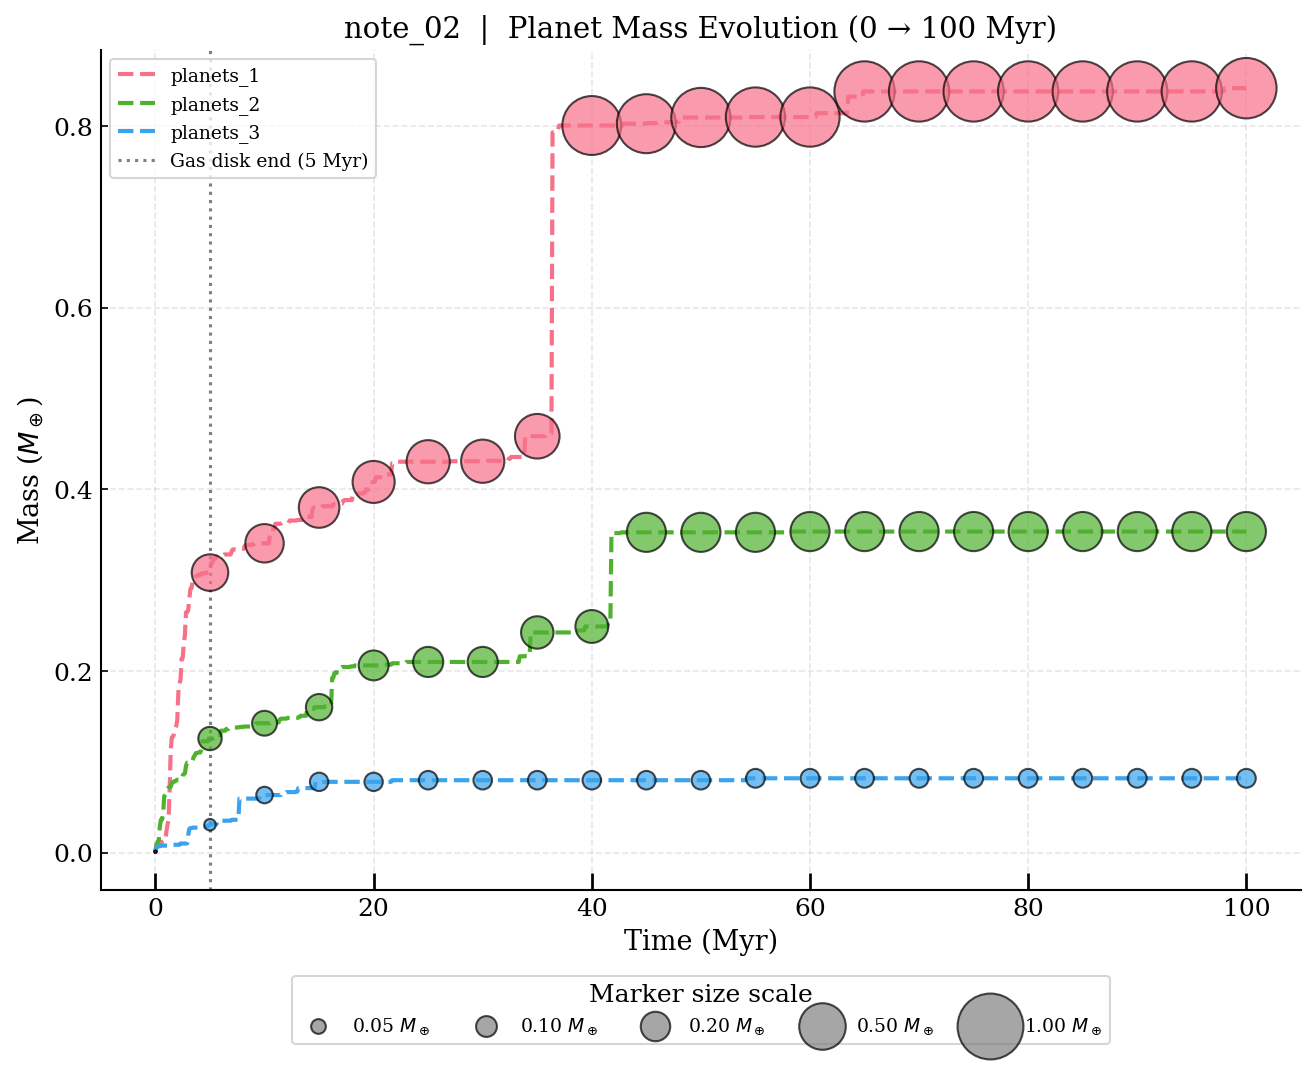

In [6]:
# ── 3.1 Visualize Mass Evolution (Full Simulation: 0 → 100 Myr) ─────────
m_cols = [col for col in df_history.columns if col.startswith('m_')]
colors_planets = sns.color_palette("husl", n_colors=len(m_cols))

fig = plt.figure(figsize=(10, 8))
ax = fig.add_axes([0.1, 0.2, 0.8, 0.7])

for i, col in enumerate(m_cols):
    ax.plot(df_history['Time'], df_history[col],
            linestyle='--', linewidth=2, color=colors_planets[i], label=keys_planets[i])
    # Scatter every 5 Myr
    mask = (np.round(df_history['Time'] % 5, 6) == 0)
    ax.scatter(df_history['Time'][mask], df_history[col][mask],
               s=df_history[col][mask] * 1000,
               color=colors_planets[i], alpha=0.7, edgecolors='k', zorder=3)

ax.axvline(5.0, color='gray', linestyle=':', linewidth=1.5, label='Gas disk end (5 Myr)')
ax.set_xlabel('Time (Myr)', fontsize=13)
ax.set_ylabel('Mass ($M_\\oplus$)', fontsize=13)
ax.set_title(f'{model}  |  Planet Mass Evolution (0 → 100 Myr)', fontsize=14)
ax.legend(loc='upper left', fontsize=9, frameon=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3, ls='--')

# ── Mass scale legend ────────────────────────────────────
sizes = [0.05, 0.10, 0.20, 0.50, 1.00]
handles = [plt.scatter([], [], s=s*1000, color='gray', alpha=0.7, edgecolors='k') for s in sizes]
labels = [f'{s:.2f} $M_\\oplus$' for s in sizes]
legend_ax = fig.add_axes([0.1, 0.05, 0.8, 0.10])
legend_ax.axis('off')
legend_ax.legend(handles, labels, loc='center', ncol=len(sizes),
                 frameon=True, title='Marker size scale', fontsize=9)

plt.show()

In [7]:

# ────────────────────────────────────────────────────────────────────────────
# Section 4: Post-Gas-Disk Collision Analysis
# ────────────────────────────────────────────────────────────────────────────
# markdown_cell: """
# ## 4. Post-Gas-Disk Collision Analysis (t > 5 Myr)
# 
# Gas giant migration typically completes within the first 5 Myr, after which 
# the disk disperses. We focus on the post-disk accretion phase where 
# terrestrial planets continue to grow through giant-impact collisions.
# 
# ### Workflow:
# 1. Filter collisions occurring after $t_{\text{gas}} = 5$ Myr
# 2. Use `CollisionTracer` to reconstruct each planet's full merger tree
# 3. Visualize accretion event timelines
# """

# ── 4.1 Filter Post-Disk Collisions ──────────────────
gas_time_yr = A_dict['5.0 Myr']['t'].iloc[0]
C_nogas = C_data[C_data['time'] > gas_time_yr].copy()
C_nogas['product_id'] = C_nogas.apply(ad.resolve_product_id, axis=1)

collision_df = (
    C_nogas[['time', 'indexi', 'm_ei', 'indexj', 'm_ej', 'product_id']]
    .sort_values('time')
    .reset_index(drop=True)
)

print(f"Gas disk end time  : {gas_time_yr/1e6:.1f} Myr ({gas_time_yr:.0e} yr)")
print(f"Total collisions   : {len(C_data)}")
print(f"Pre-disk           : {len(C_data) - len(collision_df)}")
print(f"Post-disk          : {len(collision_df)}")
print()
print("First 5 post-disk collisions:")
print(collision_df.head(6).to_string())
print()


Gas disk end time  : 4.9 Myr (5e+06 yr)
Total collisions   : 5790
Pre-disk           : 5263
Post-disk          : 527

First 5 post-disk collisions:
           time  indexi      m_ei  indexj      m_ej  product_id
0  4.929140e+06    6421  0.018042    6902  0.000814      6421.0
1  4.930942e+06    6604  0.001819    6829  0.000685      6604.0
2  4.935332e+06    6243  0.013290    4586  0.000978      6243.0
3  4.937856e+06    4189  0.308318    6654  0.000834      4189.0
4  4.938910e+06    3901  0.016796    2384  0.002257      3901.0
5  4.964972e+06    6439  0.001084    5522  0.000907      6439.0



In [8]:
# ── 4.2 Trace Full Collision Histories ───────────────
# markdown_cell: """
# ### 4.2 Trace Full Collision Histories
# 
# The `CollisionTracer.trace_full_history()` method reconstructs the complete 
# **merger tree** for each final planet by following the `product_id` chain 
# backward through time, recovering all collision events in its ancestry.
# 
# **Output:** For each planet, a DataFrame with:
# - `time`, `Time` — collision time (yr, Myr)
# - `indexi`, `indexj` — colliding particle indices
# - `m_ei`, `m_ej` — masses at collision ($M_\oplus$)
# - `Mass` — total collision mass ($m_i + m_j$)
# - `product_id` — surviving particle
# """

tracer = ad.CollisionTracer(collision_df)
dict_history = {}

for key, index in zip(keys_planets, planets_index):
    h = tracer.trace_full_history(index)
    h['Time'] = h['time'] / 1e6
    h['Mass'] = h['m_ei'] + h['m_ej']
    dict_history[key] = h

print(f"✅ Collision history tracing complete.")
print()
for key in keys_planets[:3]:  # Show first 3
    print(f"{key}: {len(dict_history[key])} collision events")
print()
print(f"Example: {keys_planets[0]}")
print(dict_history[keys_planets[0]][['Time', 'indexi', 'indexj', 'm_ei', 'm_ej', 'Mass', 'product_id']].head(6).to_string())
print()


✅ Collision history tracing complete.

planets_1: 142 collision events
planets_2: 96 collision events
planets_3: 26 collision events

Example: planets_1
       Time  indexi  indexj      m_ei      m_ej      Mass  product_id
0  4.930942    6604    6829  0.001819  0.000685  0.002504        6604
1  4.935332    6243    4586  0.013290  0.000978  0.014268        6243
2  4.937856    4189    6654  0.308318  0.000834  0.309152        4189
3  4.964972    6439    5522  0.001084  0.000907  0.001991        6439
4  5.019652    4189    1955  0.309152  0.009635  0.318787        4189
5  5.026225     250    1178  0.004953  0.000909  0.005863         250



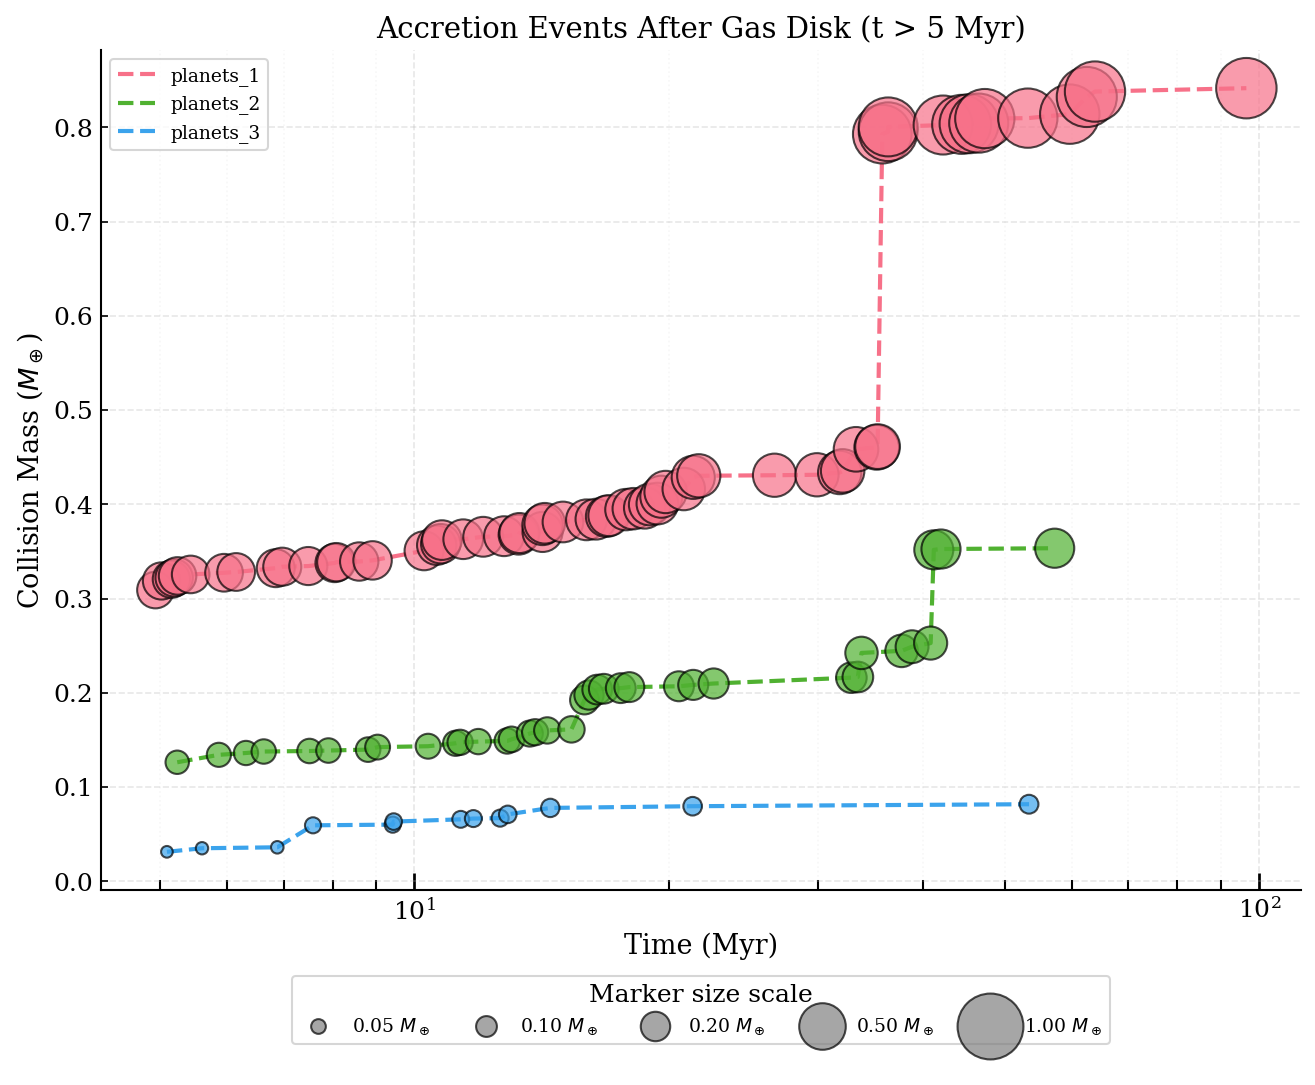

In [9]:

# ── 4.3 Visualize Post-Gas-Disk Accretion Events ─────
# markdown_cell: """
# ### 4.3 Visualize Accretion Events (Log-Scale)
# 
# Plot collision events where each planet was the **product** (survivor).
# 
# **Layout:**
# - X-axis: time (log scale, Myr), to highlight early high-energy collisions
# - Y-axis: total mass of collision event ($M_\oplus$)
# - Marker size: proportional to collision mass
# """

colors_planets = sns.color_palette("husl", n_colors=len(keys_planets))

fig = plt.figure(figsize=(10, 8))
ax = fig.add_axes([0.1, 0.2, 0.8, 0.7])

for i, (key, index) in enumerate(zip(keys_planets, planets_index)):
    df_p = dict_history[key][dict_history[key]['product_id'] == index]
    x, y = df_p['Time'], df_p['Mass']
    ax.plot(x, y, linestyle='--', linewidth=2, color=colors_planets[i], label=key, zorder=2)
    ax.scatter(x, y, s=y * 1000, color=colors_planets[i], alpha=0.7, edgecolors='k', zorder=3)

ax.set_xscale('log')
ax.set_xlabel('Time (Myr)', fontsize=13)
ax.set_ylabel('Collision Mass ($M_\\oplus$)', fontsize=13)
ax.set_title(f'Accretion Events After Gas Disk (t > 5 Myr)', fontsize=14)
ax.legend(loc='upper left', fontsize=9, frameon=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, which='major', alpha=0.3, ls='--')
ax.grid(True, which='minor', alpha=0.1, ls=':')

# ── Mass scale legend ────────────────────────────────────
sizes = [0.05, 0.10, 0.20, 0.50, 1.00]
handles = [plt.scatter([], [], s=s*1000, color='gray', alpha=0.7, edgecolors='k') for s in sizes]
labels = [f'{s:.2f} $M_\\oplus$' for s in sizes]
legend_ax = fig.add_axes([0.1, 0.05, 0.8, 0.10])
legend_ax.axis('off')
legend_ax.legend(handles, labels, loc='center', ncol=len(sizes),
                 frameon=True, title='Marker size scale', fontsize=9)

plt.show()


In [10]:
# ────────────────────────────────────────────────────────────────────────────
# Section 5: Export & Summary
# ────────────────────────────────────────────────────────────────────────────
# markdown_cell: """
# ## 5. Export Collision Histories to Excel
# 
# Each planet's collision history is saved as a separate sheet in an Excel 
# workbook, facilitating further analysis and data sharing.
# """
save_dir = pathlib.Path('./Tables')
save_dir.mkdir(parents=True, exist_ok=True)
# ✅ 修复：使用格式化字符串创建文件名
filename = f'{model}_collision_history.xlsx'
save_file = save_dir / filename
with pd.ExcelWriter(save_file) as writer:
    for key, df in dict_history.items():
        df.to_excel(writer, sheet_name=key, index=False)

print(f"✅ Exported: {save_file}")
print()

# Verify
D = pd.read_excel(save_file, sheet_name=None)
print(f"Excel sheets: {list(D.keys())}")
print()

✅ Exported: Tables/note_02_collision_history.xlsx

Excel sheets: ['planets_1', 'planets_2', 'planets_3']

